# Jacobian Exploration: SCA→SCA Dispersion Mapping

**Goal:** Characterize the 2×2 Jacobian of the SCA→SCA dispersion mapping to understand
shear/stretch magnitude across the detector and wavelength range.

This informs the galaxy disperser design:
1. How close is J to identity? (Can we approximate J≈I?)
2. Is there systematic shear? (Off-diagonal terms)
3. For a typical galaxy, what's the maximum position error if we ignore the Jacobian?

**Method:** Use JAX autodiff to compute `∂(x',y')/∂(x,y)` where `(x',y')` is the
dispersed SCA position and `(x,y)` is the undispersed SCA position, at fixed wavelength.

In [1]:
# Imports
import os
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import jax
import jax.numpy as jnp

from roman_disperser.optical_model import RomanOpticalModel
import roman_disperser.optical_model_jax as omj

plt.rcParams['font.size'] = 11

In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================

SCA = 5
ORDER = "1"

# Spatial grid across detector
N_GRID = 5
X_RANGE = (500.0, 3500.0)
Y_RANGE = (500.0, 3500.0)

# Wavelength grid
WL_MIN = 0.9   # microns
WL_MAX = 2.0   # microns
N_WL = 23

# Galaxy sizes for position error estimate (oversampled pixels at 4× oversampling)
GALAXY_HALF_SIZES_NATIVE = [6, 12, 25]  # native pixels (half-width)
OVERSAMPLE = 4

print(f"Configuration:")
print(f"  SCA: {SCA}, Order: {ORDER}")
print(f"  Spatial grid: {N_GRID}×{N_GRID} from ({X_RANGE[0]}, {Y_RANGE[0]}) to ({X_RANGE[1]}, {Y_RANGE[1]})")
print(f"  Wavelength grid: {N_WL} points from {WL_MIN} to {WL_MAX} μm")
print(f"  Galaxy half-sizes (native pixels): {GALAXY_HALF_SIZES_NATIVE}")

Configuration:
  SCA: 5, Order: 1
  Spatial grid: 5×5 from (500.0, 500.0) to (3500.0, 3500.0)
  Wavelength grid: 23 points from 0.9 to 2.0 μm
  Galaxy half-sizes (native pixels): [6, 12, 25]


## Load Model and Create Payload

In [3]:
project_root = Path(os.environ.get("PIXI_PROJECT_ROOT", "."))
config_path = project_root / "data" / "Roman_grism_OpticalModel_v0.8.yaml"

model = RomanOpticalModel(config_file=str(config_path))
payload = omj.make_sca_payload(model, sca=SCA, order=ORDER)

print(f"Model loaded: wl_ref = {float(payload['wl']['reference']):.2f} μm")
print(f"Detector: {payload['det']['naxis1']}×{payload['det']['naxis2']} pixels")

Model loaded: wl_ref = 1.55 μm
Detector: 4088×4088 pixels


## Define SCA→SCA Trace and Jacobian Functions

The optical model functions expect 1D arrays, but `jax.jacobian` needs scalar
differentiation. We wrap with `jnp.atleast_1d` and extract scalars.

In [4]:
def trace_beam_sca(payload, xsca, ysca, wavelength):
    """Trace position through optical model: SCA → FPA → MPA → SCA.
    
    Accepts scalar inputs (wraps to 1D arrays for optical model functions).
    """
    xsca_a = jnp.atleast_1d(xsca)
    ysca_a = jnp.atleast_1d(ysca)
    wl_a = jnp.atleast_1d(wavelength)
    xfpa, yfpa = omj.sca_to_fpa(payload, xsca_a, ysca_a)
    xmpa, ympa = omj.trace_beam(payload, xfpa, yfpa, wl_a)
    x_out, y_out = omj.mpa_to_sca(payload, xmpa, ympa)
    return x_out[0], y_out[0]


def make_jacobian_fn(payload):
    """Create a JIT-compiled Jacobian function with payload captured in closure.
    
    Returns a function: (xsca, ysca, wavelength) -> J[2, 2]
    """
    def _compute_jacobian(xsca, ysca, wavelength):
        jac_raw = jax.jacobian(trace_beam_sca, argnums=(1, 2))(
            payload, xsca, ysca, wavelength
        )
        # jac_raw = ((∂x'/∂x, ∂x'/∂y), (∂y'/∂x, ∂y'/∂y))
        return jnp.array([[jac_raw[0][0], jac_raw[0][1]],
                          [jac_raw[1][0], jac_raw[1][1]]])
    
    return jax.jit(_compute_jacobian)


# Create JIT-compiled Jacobian function (payload captured in closure)
compute_jacobian = make_jacobian_fn(payload)

# Quick test at detector center and reference wavelength
x_test, y_test = 2044.0, 2044.0
wl_test = float(payload['wl']['reference'])

# Warm up JIT
J_test = compute_jacobian(jnp.float32(x_test), jnp.float32(y_test), jnp.float32(wl_test))
J_test.block_until_ready()

print(f"Jacobian at center, λ={wl_test} μm (reference wavelength):")
print(f"  J = [[{J_test[0,0]:.6f}, {J_test[0,1]:.6f}],")
print(f"       [{J_test[1,0]:.6f}, {J_test[1,1]:.6f}]]")
print(f"  ||J - I||_F = {jnp.linalg.norm(J_test - jnp.eye(2)):.2e}")

Jacobian at center, λ=1.5499999523162842 μm (reference wavelength):
  J = [[0.991384, -0.011496],
       [-0.012439, 1.020179]]


  ||J - I||_F = 2.77e-02


## Finite-Difference Validation

Verify the autodiff Jacobian matches numerical finite differences.

**Note:** Must use float64 for finite differences — the output positions are ~2044 and
differ by ~2e-3, so float32's ~7 digits of precision causes catastrophic cancellation.

In [5]:
# Enable float64 for accurate finite differences
jax.config.update("jax_enable_x64", True)

eps = 1e-4  # finite difference step (pixels)

x0 = jnp.float64(2044.0)
y0 = jnp.float64(2044.0)
wl0 = jnp.float64(1.2)

# Autodiff Jacobian in float64
compute_jacobian_f64 = make_jacobian_fn(payload)
J_auto = compute_jacobian_f64(x0, y0, wl0)

# Finite difference Jacobian in float64
x_p, y_p = trace_beam_sca(payload, x0 + eps, y0, wl0)
x_m, y_m = trace_beam_sca(payload, x0 - eps, y0, wl0)
dxdx_fd = (x_p - x_m) / (2 * eps)
dydx_fd = (y_p - y_m) / (2 * eps)

x_p, y_p = trace_beam_sca(payload, x0, y0 + eps, wl0)
x_m, y_m = trace_beam_sca(payload, x0, y0 - eps, wl0)
dxdy_fd = (x_p - x_m) / (2 * eps)
dydy_fd = (y_p - y_m) / (2 * eps)

J_fd = np.array([[float(dxdx_fd), float(dxdy_fd)],
                 [float(dydx_fd), float(dydy_fd)]])

print(f"Autodiff Jacobian at (2044, 2044), λ=1.2 μm (float64):")
print(f"  {np.array(J_auto)}")
print(f"Finite-difference Jacobian (float64, eps={eps}):")
print(f"  {J_fd}")
print(f"Max absolute difference: {np.max(np.abs(np.array(J_auto) - J_fd)):.2e}")
print(f"Max relative difference: {np.max(np.abs(np.array(J_auto) - J_fd) / (np.abs(J_fd) + 1e-30)):.2e}")

# Disable float64 for rest of notebook (use default float32 for performance)
jax.config.update("jax_enable_x64", False)

# Recreate the float32 Jacobian function (JIT cache was invalidated by dtype change)
compute_jacobian = make_jacobian_fn(payload)

Autodiff Jacobian at (2044, 2044), λ=1.2 μm (float64):
  [[ 0.99273558 -0.01196479]
 [-0.01294688  1.02300906]]
Finite-difference Jacobian (float64, eps=0.0001):
  [[ 0.9927356  -0.01196479]
 [-0.01294688  1.02300906]]
Max absolute difference: 2.25e-08
Max relative difference: 5.84e-08


## Compute Jacobian Across Detector and Wavelength

Evaluate J at a 5×5 spatial grid × 23 wavelengths.

In [6]:
x_grid = np.linspace(X_RANGE[0], X_RANGE[1], N_GRID)
y_grid = np.linspace(Y_RANGE[0], Y_RANGE[1], N_GRID)
wl_grid = np.linspace(WL_MIN, WL_MAX, N_WL)

# Store Jacobians: [N_y, N_x, N_wl, 2, 2]
jacobians = np.zeros((N_GRID, N_GRID, N_WL, 2, 2))

t0 = time.time()
for iy, yy in enumerate(y_grid):
    for ix, xx in enumerate(x_grid):
        for iw, ww in enumerate(wl_grid):
            J = compute_jacobian(jnp.float32(xx), jnp.float32(yy), jnp.float32(ww))
            jacobians[iy, ix, iw] = np.array(J)

elapsed = time.time() - t0
n_evals = N_GRID * N_GRID * N_WL
print(f"Computed {n_evals} Jacobians in {elapsed:.1f}s ({elapsed/n_evals*1000:.1f} ms/eval)")

Computed 575 Jacobians in 0.2s (0.4 ms/eval)


## Analysis 1: ||J - I|| Frobenius Norm

How far is the Jacobian from identity?

In [7]:
# Compute ||J - I||_F for all grid points
I2 = np.eye(2)
j_minus_i = jacobians - I2[np.newaxis, np.newaxis, np.newaxis, :, :]
frob_norm = np.sqrt(np.sum(j_minus_i**2, axis=(-2, -1)))  # [N_y, N_x, N_wl]

print(f"||J - I||_F statistics:")
print(f"  Min:    {frob_norm.min():.6f}")
print(f"  Max:    {frob_norm.max():.6f}")
print(f"  Mean:   {frob_norm.mean():.6f}")
print(f"  Median: {np.median(frob_norm):.6f}")

||J - I||_F statistics:
  Min:    0.020598
  Max:    0.043026
  Mean:   0.029125
  Median: 0.028546


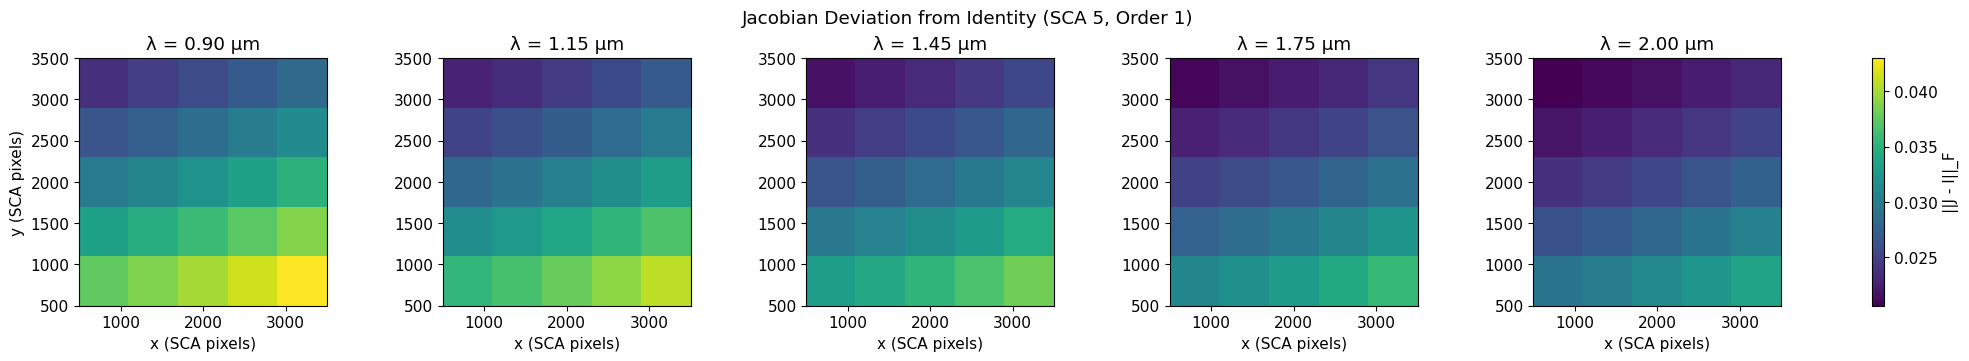

In [8]:
# Heatmaps of ||J - I|| at a few wavelengths
wl_indices = [0, N_WL // 4, N_WL // 2, 3 * N_WL // 4, N_WL - 1]
fig, axes = plt.subplots(1, len(wl_indices), figsize=(4 * len(wl_indices), 3.5),
                         constrained_layout=True)

vmin = frob_norm.min()
vmax = frob_norm.max()

for ax, iw in zip(axes, wl_indices):
    im = ax.imshow(frob_norm[:, :, iw], origin='lower', vmin=vmin, vmax=vmax,
                   extent=[X_RANGE[0], X_RANGE[1], Y_RANGE[0], Y_RANGE[1]],
                   cmap='viridis')
    ax.set_title(f'λ = {wl_grid[iw]:.2f} μm')
    ax.set_xlabel('x (SCA pixels)')

axes[0].set_ylabel('y (SCA pixels)')
fig.colorbar(im, ax=axes, label='||J - I||_F')
fig.suptitle(f'Jacobian Deviation from Identity (SCA {SCA}, Order {ORDER})');

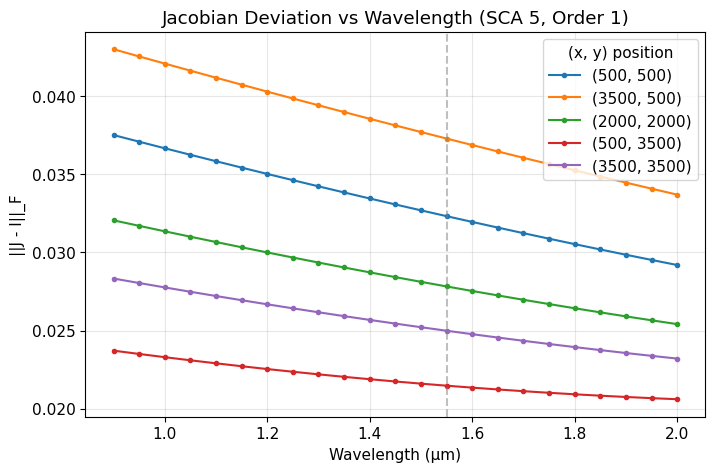

In [9]:
# ||J - I|| vs wavelength at different positions
fig, ax = plt.subplots(figsize=(8, 5))

# Plot corners and center
positions = [
    (0, 0, f'({x_grid[0]:.0f}, {y_grid[0]:.0f})'),
    (0, -1, f'({x_grid[-1]:.0f}, {y_grid[0]:.0f})'),
    (N_GRID//2, N_GRID//2, f'({x_grid[N_GRID//2]:.0f}, {y_grid[N_GRID//2]:.0f})'),
    (-1, 0, f'({x_grid[0]:.0f}, {y_grid[-1]:.0f})'),
    (-1, -1, f'({x_grid[-1]:.0f}, {y_grid[-1]:.0f})'),
]

for iy, ix, label in positions:
    ax.plot(wl_grid, frob_norm[iy, ix, :], '-o', markersize=3, label=label)

ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('||J - I||_F')
ax.set_title(f'Jacobian Deviation vs Wavelength (SCA {SCA}, Order {ORDER})')
ax.legend(title='(x, y) position')
ax.grid(True, alpha=0.3)
ax.axvline(float(payload['wl']['reference']), color='gray', ls='--', alpha=0.5, label='wl_ref');

## Analysis 2: Jacobian Components

Examine diagonal (stretch) and off-diagonal (shear) terms separately.

In [10]:
# Extract components
J00 = jacobians[:, :, :, 0, 0]  # ∂x'/∂x
J01 = jacobians[:, :, :, 0, 1]  # ∂x'/∂y
J10 = jacobians[:, :, :, 1, 0]  # ∂y'/∂x
J11 = jacobians[:, :, :, 1, 1]  # ∂y'/∂y

print("Jacobian component statistics:")
for name, comp in [("J[0,0] (∂x'/∂x)", J00), ("J[1,1] (∂y'/∂y)", J11),
                    ("J[0,1] (∂x'/∂y)", J01), ("J[1,0] (∂y'/∂x)", J10)]:
    print(f"  {name}: min={comp.min():.6f}, max={comp.max():.6f}, "
          f"mean={comp.mean():.6f}, std={comp.std():.6f}")

Jacobian component statistics:
  J[0,0] (∂x'/∂x): min=0.985284, max=0.999528, mean=0.991972, std=0.002813
  J[1,1] (∂y'/∂y): min=1.008804, max=1.035790, mean=1.021437, std=0.006403
  J[0,1] (∂x'/∂y): min=-0.016171, max=-0.007821, mean=-0.011590, std=0.001967
  J[1,0] (∂y'/∂x): min=-0.017568, max=-0.008309, mean=-0.012532, std=0.002232


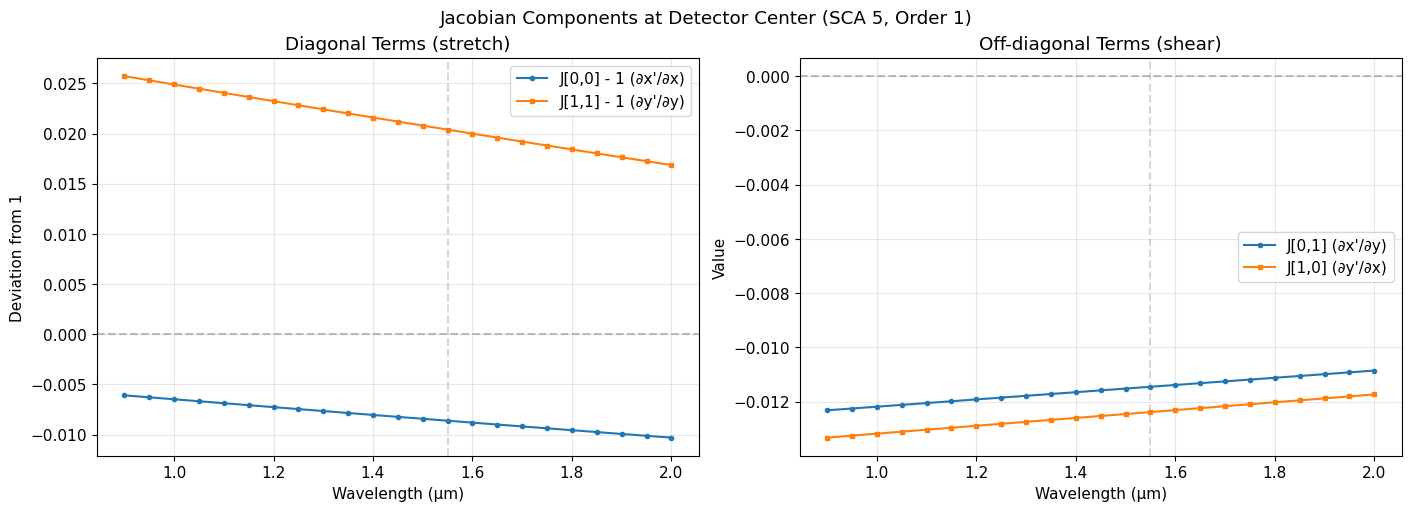

In [11]:
# Jacobian components vs wavelength at detector center
ic = N_GRID // 2  # center index

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Diagonal terms (deviation from 1)
ax = axes[0]
ax.plot(wl_grid, J00[ic, ic, :] - 1, '-o', markersize=3, label="J[0,0] - 1 (∂x'/∂x)")
ax.plot(wl_grid, J11[ic, ic, :] - 1, '-s', markersize=3, label="J[1,1] - 1 (∂y'/∂y)")
ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('Deviation from 1')
ax.set_title('Diagonal Terms (stretch)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.axvline(float(payload['wl']['reference']), color='gray', ls='--', alpha=0.3)

# Off-diagonal terms
ax = axes[1]
ax.plot(wl_grid, J01[ic, ic, :], '-o', markersize=3, label="J[0,1] (∂x'/∂y)")
ax.plot(wl_grid, J10[ic, ic, :], '-s', markersize=3, label="J[1,0] (∂y'/∂x)")
ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('Value')
ax.set_title('Off-diagonal Terms (shear)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.axvline(float(payload['wl']['reference']), color='gray', ls='--', alpha=0.3)

fig.suptitle(f'Jacobian Components at Detector Center (SCA {SCA}, Order {ORDER})');

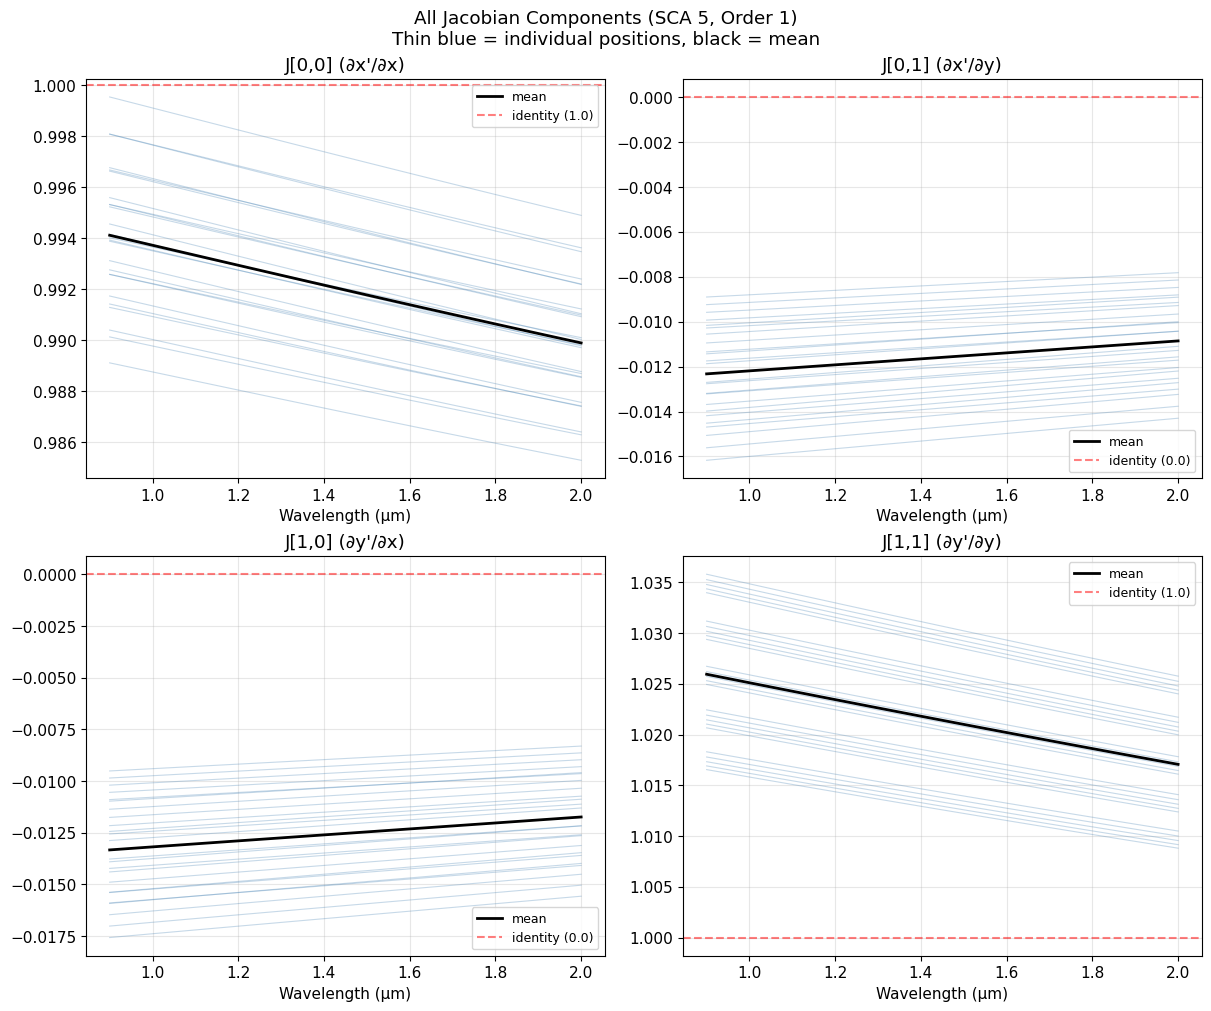

In [12]:
# All 4 components vs wavelength at all positions (to see spread)
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

components = [(J00, "J[0,0] (∂x'/∂x)", 1.0), (J01, "J[0,1] (∂x'/∂y)", 0.0),
              (J10, "J[1,0] (∂y'/∂x)", 0.0), (J11, "J[1,1] (∂y'/∂y)", 1.0)]

for ax, (comp, title, identity_val) in zip(axes.flat, components):
    # Plot all positions as thin lines
    for iy in range(N_GRID):
        for ix in range(N_GRID):
            ax.plot(wl_grid, comp[iy, ix, :], '-', alpha=0.3, color='steelblue', linewidth=0.8)
    # Mean over all positions
    ax.plot(wl_grid, comp.mean(axis=(0, 1)), '-k', linewidth=2, label='mean')
    ax.axhline(identity_val, color='red', ls='--', alpha=0.5, label=f'identity ({identity_val})')
    ax.set_xlabel('Wavelength (μm)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'All Jacobian Components (SCA {SCA}, Order {ORDER})\n'
             f'Thin blue = individual positions, black = mean');

## Analysis 3: Position Error for Galaxy-Sized Objects

For a galaxy with half-size $r$ pixels, the maximum position error from using $J = I$ is:

$$\delta_{\max} = \|J - I\|_F \cdot r$$

Compare this to the pixel scale (1 native pixel = 0.11 arcsec) and oversampled pixel (0.0275 arcsec).

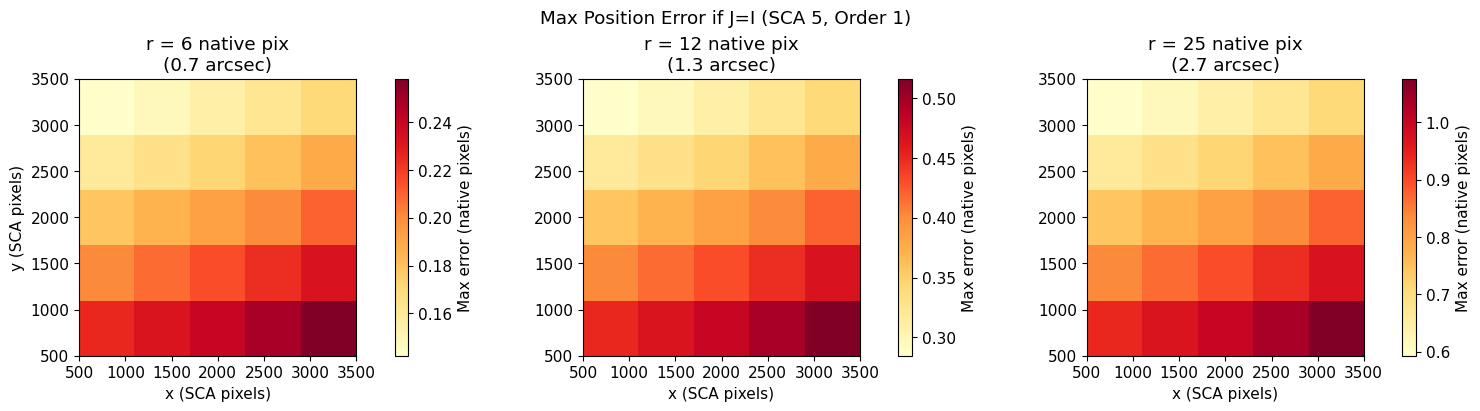

In [13]:
# Position error at each grid point for different galaxy sizes
fig, axes = plt.subplots(1, len(GALAXY_HALF_SIZES_NATIVE), figsize=(5 * len(GALAXY_HALF_SIZES_NATIVE), 4),
                         constrained_layout=True)

pixel_scale = float(payload['det']['pixel_scale'])  # arcsec/pixel

for ax, half_size in zip(axes, GALAXY_HALF_SIZES_NATIVE):
    # Max position error across all wavelengths for this galaxy size (in native pixels)
    max_error_pixels = frob_norm.max(axis=2) * half_size  # [N_y, N_x]
    max_error_arcsec = max_error_pixels * pixel_scale
    
    im = ax.imshow(max_error_pixels, origin='lower',
                   extent=[X_RANGE[0], X_RANGE[1], Y_RANGE[0], Y_RANGE[1]],
                   cmap='YlOrRd')
    fig.colorbar(im, ax=ax, label='Max error (native pixels)')
    ax.set_title(f'r = {half_size} native pix\n({half_size * pixel_scale:.1f} arcsec)')
    ax.set_xlabel('x (SCA pixels)')

axes[0].set_ylabel('y (SCA pixels)')
fig.suptitle(f'Max Position Error if J=I (SCA {SCA}, Order {ORDER})');

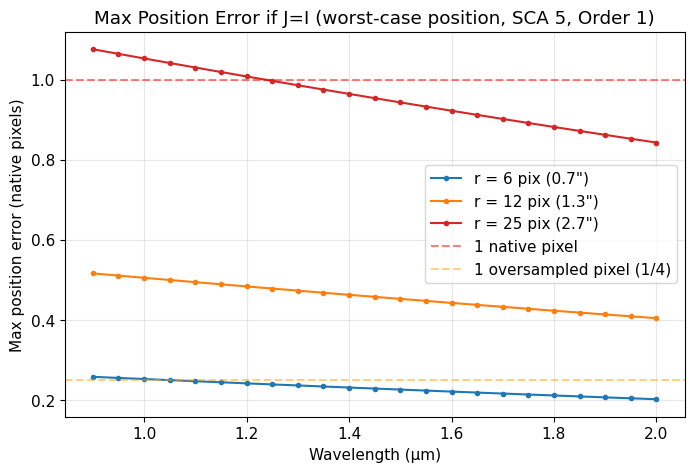

In [14]:
# Position error vs wavelength for galaxy half-sizes
fig, ax = plt.subplots(figsize=(8, 5))

# Use max over all positions
frob_max_vs_wl = frob_norm.max(axis=(0, 1))  # [N_wl]

colors = plt.cm.tab10(np.linspace(0, 0.3, len(GALAXY_HALF_SIZES_NATIVE)))
for half_size, color in zip(GALAXY_HALF_SIZES_NATIVE, colors):
    error_pixels = frob_max_vs_wl * half_size
    ax.plot(wl_grid, error_pixels, '-o', markersize=3, color=color,
            label=f'r = {half_size} pix ({half_size * pixel_scale:.1f}")')

ax.axhline(1.0, color='red', ls='--', alpha=0.5, label='1 native pixel')
ax.axhline(1.0 / OVERSAMPLE, color='orange', ls='--', alpha=0.5,
           label=f'1 oversampled pixel (1/{OVERSAMPLE})')

ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('Max position error (native pixels)')
ax.set_title(f'Max Position Error if J=I (worst-case position, SCA {SCA}, Order {ORDER})')
ax.legend()
ax.grid(True, alpha=0.3);

In [15]:
# Summary table
print(f"Position error summary (worst-case across all positions and wavelengths):")
print(f"{'Galaxy half-size':>20s}  {'Max error (native pix)':>22s}  {'Max error (arcsec)':>18s}  {'Max error (oversampled pix)':>27s}")
print(f"{'-'*20:>20s}  {'-'*22:>22s}  {'-'*18:>18s}  {'-'*27:>27s}")

frob_worst = frob_norm.max()
for half_size in GALAXY_HALF_SIZES_NATIVE:
    err_pix = frob_worst * half_size
    err_arcsec = err_pix * pixel_scale
    err_oversamp = err_pix * OVERSAMPLE
    print(f"{half_size:>17d} pix  {err_pix:>22.4f}  {err_arcsec:>15.4f}\"  {err_oversamp:>27.2f}")

Position error summary (worst-case across all positions and wavelengths):
    Galaxy half-size  Max error (native pix)  Max error (arcsec)  Max error (oversampled pix)
--------------------  ----------------------  ------------------  ---------------------------
                6 pix                  0.2582           0.0284"                         1.03
               12 pix                  0.5163           0.0568"                         2.07
               25 pix                  1.0757           0.1183"                         4.30


## Analysis 4: Variation Across SCAs

Quick check: how does the Jacobian differ across a few SCAs?

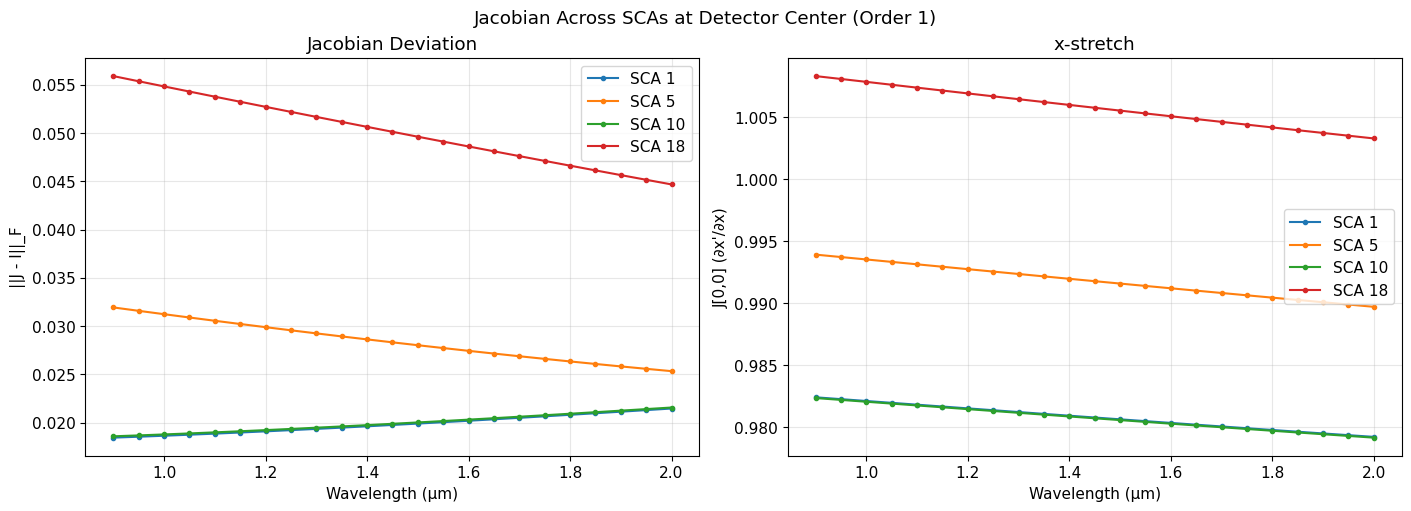

In [16]:
# Compare a few SCAs at detector center across wavelengths
scas_to_check = [1, 5, 10, 18]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

x_center, y_center = jnp.float32(2044.0), jnp.float32(2044.0)

for sca in scas_to_check:
    p = omj.make_sca_payload(model, sca=sca, order=ORDER)
    jac_fn = make_jacobian_fn(p)
    
    norms = []
    j00_vals = []
    for wl in wl_grid:
        J = jac_fn(x_center, y_center, jnp.float32(wl))
        norms.append(float(jnp.linalg.norm(J - jnp.eye(2))))
        j00_vals.append(float(J[0, 0]))
    
    axes[0].plot(wl_grid, norms, '-o', markersize=3, label=f'SCA {sca}')
    axes[1].plot(wl_grid, j00_vals, '-o', markersize=3, label=f'SCA {sca}')

axes[0].set_xlabel('Wavelength (μm)')
axes[0].set_ylabel('||J - I||_F')
axes[0].set_title('Jacobian Deviation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Wavelength (μm)')
axes[1].set_ylabel("J[0,0] (∂x'/∂x)")
axes[1].set_title('x-stretch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle(f'Jacobian Across SCAs at Detector Center (Order {ORDER})');

## Analysis 5: Jacobian Approximation vs Exact Trace

The previous analyses estimated position error from ||J - I||, which bounds the error from
using J = **I** (identity). Now we test how well the actual Jacobian linear approximation
reproduces the full nonlinear dispersion:

- **Exact relative displacement**: `trace(x0+Δx, y0+Δy, λ) - trace(x0, y0, λ)`
- **Jacobian approximation**: `J @ [Δx, Δy]`
- **Residual**: difference (this is the second-order Taylor remainder, should scale as r²)

In [17]:
# Enable float64 for Analysis 5 — same cancellation issue as finite differences.
# Output positions are ~2044, so subtracting trace(x0+Δx) - trace(x0) loses precision
# in float32 when Δx is small.
jax.config.update("jax_enable_x64", True)
compute_jacobian_f64 = make_jacobian_fn(payload)


def trace_beam_sca_array(payload, xsca, ysca, wavelength):
    """Vectorized SCA→SCA trace for arrays of positions at a single wavelength.

    Args:
        xsca, ysca: [N] arrays of SCA positions
        wavelength: scalar wavelength (microns)
    Returns:
        x_out, y_out: [N] dispersed SCA positions
    """
    wl_arr = jnp.full_like(xsca, wavelength)
    xfpa, yfpa = omj.sca_to_fpa(payload, xsca, ysca)
    xmpa, ympa = omj.trace_beam(payload, xfpa, yfpa, wl_arr)
    return omj.mpa_to_sca(payload, xmpa, ympa)


def compute_jacobian_residuals(payload, x0, y0, wavelength, offsets_x, offsets_y):
    """Compare exact trace vs Jacobian approximation for a grid of offsets.

    Uses float64 to avoid catastrophic cancellation when subtracting
    nearby output positions.

    Args:
        x0, y0: center position (SCA pixels)
        wavelength: scalar wavelength (microns)
        offsets_x, offsets_y: [N] arrays of offsets from center (native pixels)

    Returns:
        exact_dx, exact_dy: [N] exact relative displacements
        approx_dx, approx_dy: [N] Jacobian-approximated displacements
        residual: [N] ||exact - approx|| (native pixels)
    """
    # Exact: trace each offset position (float64)
    x_exact, y_exact = trace_beam_sca_array(
        payload,
        jnp.array(x0 + offsets_x, dtype=jnp.float64),
        jnp.array(y0 + offsets_y, dtype=jnp.float64),
        float(wavelength),
    )
    # Exact center position (float64)
    x_center, y_center = trace_beam_sca(
        payload, jnp.float64(x0), jnp.float64(y0), jnp.float64(wavelength)
    )

    # Exact relative displacements
    exact_dx = np.array(x_exact - x_center, dtype=np.float64)
    exact_dy = np.array(y_exact - y_center, dtype=np.float64)

    # Jacobian approximation (float64 Jacobian)
    J = np.array(compute_jacobian_f64(jnp.float64(x0), jnp.float64(y0), jnp.float64(wavelength)),
                 dtype=np.float64)
    offsets = np.stack([offsets_x, offsets_y], axis=-1).astype(np.float64)
    approx = offsets @ J.T  # [N, 2]
    approx_dx = approx[:, 0]
    approx_dy = approx[:, 1]

    # Residual
    residual = np.sqrt((exact_dx - approx_dx)**2 + (exact_dy - approx_dy)**2)

    return exact_dx, exact_dy, approx_dx, approx_dy, residual

In [18]:
# Compute residuals on a 2D offset grid at detector center, λ=1.2 μm
MAX_OFFSET = 25  # native pixels (half-width of largest galaxy)
N_OFFSET = 51    # grid resolution

offset_1d = np.linspace(-MAX_OFFSET, MAX_OFFSET, N_OFFSET)
off_x_2d, off_y_2d = np.meshgrid(offset_1d, offset_1d)
off_x_flat = off_x_2d.ravel()
off_y_flat = off_y_2d.ravel()
radii_flat = np.sqrt(off_x_flat**2 + off_y_flat**2)

# Test at detector center and a wavelength away from reference
test_x0, test_y0 = 2044.0, 2044.0
test_wl = 1.2  # μm

exact_dx, exact_dy, approx_dx, approx_dy, residual = compute_jacobian_residuals(
    payload, test_x0, test_y0, test_wl, off_x_flat, off_y_flat
)

residual_2d = residual.reshape(N_OFFSET, N_OFFSET)

print(f"Jacobian approximation residuals at ({test_x0}, {test_y0}), λ={test_wl} μm:")
print(f"  Max residual:  {residual.max():.6f} native pix ({residual.max() * OVERSAMPLE:.4f} oversampled)")
print(f"  Mean residual: {residual.mean():.6f} native pix")
for r_check in GALAXY_HALF_SIZES_NATIVE:
    mask = np.abs(radii_flat - r_check) < 1.5
    if mask.any():
        print(f"  At r≈{r_check:2d} (max): {residual[mask].max():.6f} native pix "
              f"({residual[mask].max() * OVERSAMPLE:.4f} oversampled)")

Jacobian approximation residuals at (2044.0, 2044.0), λ=1.2 μm:
  Max residual:  0.003288 native pix (0.0132 oversampled)
  Mean residual: 0.000911 native pix
  At r≈ 6 (max): 0.000155 native pix (0.0006 oversampled)
  At r≈12 (max): 0.000522 native pix (0.0021 oversampled)
  At r≈25 (max): 0.002029 native pix (0.0081 oversampled)


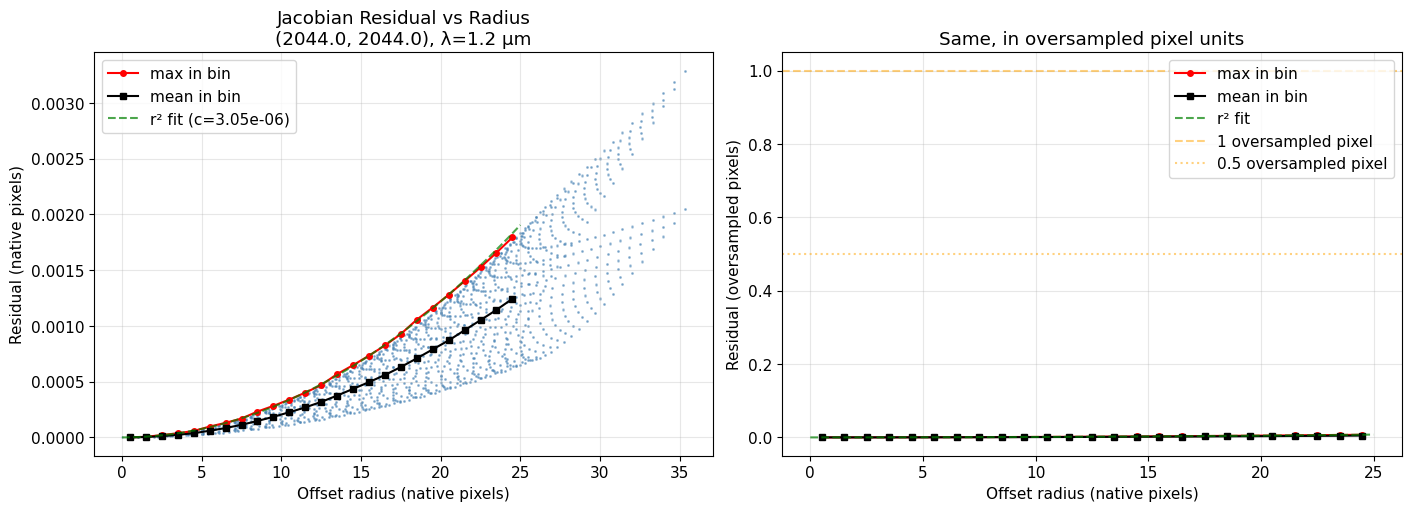

In [19]:
# Error vs offset radius — should scale as r² (second-order Taylor remainder)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Left: scatter of all points
ax = axes[0]
ax.scatter(radii_flat, residual, s=1, alpha=0.3, color='steelblue')

# Bin by radius for mean/max curves
r_bins = np.linspace(0, MAX_OFFSET, 26)
r_centers = 0.5 * (r_bins[:-1] + r_bins[1:])
max_in_bin = np.array([residual[(radii_flat >= r_bins[i]) & (radii_flat < r_bins[i+1])].max()
                       if ((radii_flat >= r_bins[i]) & (radii_flat < r_bins[i+1])).any() else 0
                       for i in range(len(r_bins) - 1)])
mean_in_bin = np.array([residual[(radii_flat >= r_bins[i]) & (radii_flat < r_bins[i+1])].mean()
                        if ((radii_flat >= r_bins[i]) & (radii_flat < r_bins[i+1])).any() else 0
                        for i in range(len(r_bins) - 1)])

ax.plot(r_centers, max_in_bin, 'r-o', markersize=4, label='max in bin')
ax.plot(r_centers, mean_in_bin, 'k-s', markersize=4, label='mean in bin')

# Overlay r² fit using max at large r
r_fit = r_centers[r_centers > 5]
max_fit = max_in_bin[r_centers > 5]
if len(r_fit) > 2:
    # Fit: residual = c * r^2
    c_fit = np.median(max_fit / r_fit**2)
    r_smooth = np.linspace(0, MAX_OFFSET, 100)
    ax.plot(r_smooth, c_fit * r_smooth**2, 'g--', alpha=0.7, label=f'r² fit (c={c_fit:.2e})')

ax.set_xlabel('Offset radius (native pixels)')
ax.set_ylabel('Residual (native pixels)')
ax.set_title(f'Jacobian Residual vs Radius\n({test_x0}, {test_y0}), λ={test_wl} μm')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: same but in oversampled pixels, with reference lines
ax = axes[1]
ax.plot(r_centers, max_in_bin * OVERSAMPLE, 'r-o', markersize=4, label='max in bin')
ax.plot(r_centers, mean_in_bin * OVERSAMPLE, 'k-s', markersize=4, label='mean in bin')
if len(r_fit) > 2:
    ax.plot(r_smooth, c_fit * r_smooth**2 * OVERSAMPLE, 'g--', alpha=0.7, label='r² fit')
ax.axhline(1.0, color='orange', ls='--', alpha=0.5, label='1 oversampled pixel')
ax.axhline(0.5, color='orange', ls=':', alpha=0.5, label='0.5 oversampled pixel')
ax.set_xlabel('Offset radius (native pixels)')
ax.set_ylabel('Residual (oversampled pixels)')
ax.set_title('Same, in oversampled pixel units')
ax.legend()
ax.grid(True, alpha=0.3);

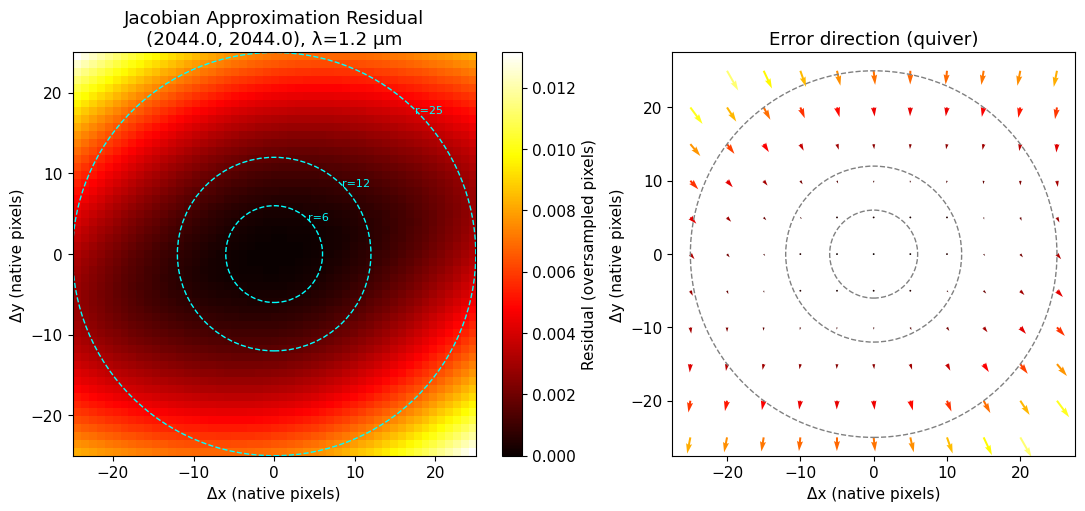

In [20]:
# 2D error map over galaxy-sized region
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Left: residual magnitude
ax = axes[0]
im = ax.imshow(residual_2d * OVERSAMPLE, origin='lower',
               extent=[-MAX_OFFSET, MAX_OFFSET, -MAX_OFFSET, MAX_OFFSET],
               cmap='hot')
fig.colorbar(im, ax=ax, label='Residual (oversampled pixels)')
for r in GALAXY_HALF_SIZES_NATIVE:
    circle = plt.Circle((0, 0), r, fill=False, color='cyan', ls='--', linewidth=1)
    ax.add_patch(circle)
    ax.annotate(f'r={r}', (r * 0.7, r * 0.7), color='cyan', fontsize=8)
ax.set_xlabel('Δx (native pixels)')
ax.set_ylabel('Δy (native pixels)')
ax.set_title(f'Jacobian Approximation Residual\n({test_x0}, {test_y0}), λ={test_wl} μm')

# Right: error direction (quiver) — subsample for readability
ax = axes[1]
step = 5  # plot every 5th point
err_dx = (exact_dx - approx_dx).reshape(N_OFFSET, N_OFFSET)
err_dy = (exact_dy - approx_dy).reshape(N_OFFSET, N_OFFSET)
ax.quiver(off_x_2d[::step, ::step], off_y_2d[::step, ::step],
          err_dx[::step, ::step], err_dy[::step, ::step],
          residual_2d[::step, ::step], cmap='hot', scale=0.05, width=0.005)
for r in GALAXY_HALF_SIZES_NATIVE:
    circle = plt.Circle((0, 0), r, fill=False, color='gray', ls='--', linewidth=1)
    ax.add_patch(circle)
ax.set_xlabel('Δx (native pixels)')
ax.set_ylabel('Δy (native pixels)')
ax.set_title('Error direction (quiver)')
ax.set_aspect('equal');

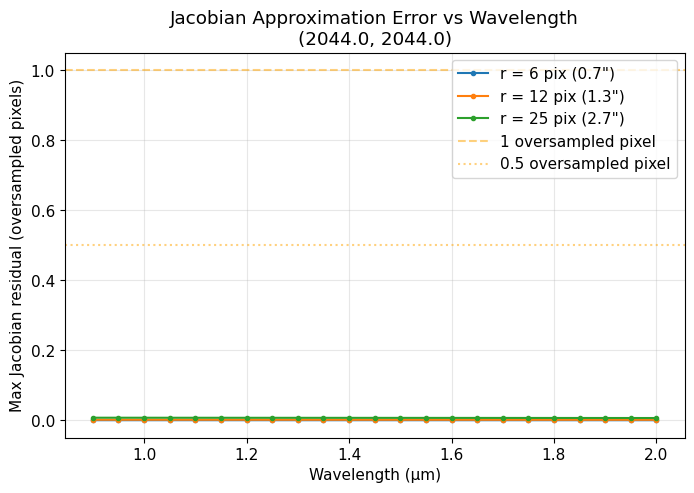

In [21]:
# Wavelength dependence: max residual at fixed radius vs wavelength
fig, ax = plt.subplots(figsize=(8, 5))

# For each galaxy size, compute max residual around a circle at each wavelength
n_circle = 36  # points around circle
theta = np.linspace(0, 2 * np.pi, n_circle, endpoint=False)

for half_size in GALAXY_HALF_SIZES_NATIVE:
    circle_dx = half_size * np.cos(theta)
    circle_dy = half_size * np.sin(theta)
    
    max_resids = []
    for wl in wl_grid:
        _, _, _, _, resid = compute_jacobian_residuals(
            payload, test_x0, test_y0, wl, circle_dx, circle_dy
        )
        max_resids.append(resid.max())
    
    ax.plot(wl_grid, np.array(max_resids) * OVERSAMPLE, '-o', markersize=3,
            label=f'r = {half_size} pix ({half_size * pixel_scale:.1f}")')

ax.axhline(1.0, color='orange', ls='--', alpha=0.5, label='1 oversampled pixel')
ax.axhline(0.5, color='orange', ls=':', alpha=0.5, label='0.5 oversampled pixel')
ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('Max Jacobian residual (oversampled pixels)')
ax.set_title(f'Jacobian Approximation Error vs Wavelength\n({test_x0}, {test_y0})')
ax.legend()
ax.grid(True, alpha=0.3);

In [22]:
# Comparison: Jacobian residual vs theoretical ||J-I||·r bound
# The ||J-I||·r bound from Analysis 3 is the error from using J=I (no Jacobian at all).
# The Jacobian residual is the error from using the linear Jacobian approximation.
# The residual should be much smaller than the bound.

print(f"Comparison: Jacobian approximation error vs J=I error")
print(f"{'Galaxy half-size':>20s}  {'J approx residual':>20s}  {'J=I bound (||J-I||r)':>22s}  {'Ratio':>8s}")
print(f"{'-'*20:>20s}  {'-'*20:>20s}  {'-'*22:>22s}  {'-'*8:>8s}")

# Use worst-case wavelength (0.9 μm — furthest from reference)
worst_wl = 0.9
for half_size in GALAXY_HALF_SIZES_NATIVE:
    # Actual Jacobian residual
    circle_dx = half_size * np.cos(theta)
    circle_dy = half_size * np.sin(theta)
    _, _, _, _, resid = compute_jacobian_residuals(
        payload, test_x0, test_y0, worst_wl, circle_dx, circle_dy
    )
    max_resid = resid.max()
    
    # Theoretical J=I bound
    J_at_wl = np.array(compute_jacobian(jnp.float32(test_x0), jnp.float32(test_y0), jnp.float32(worst_wl)))
    j_i_norm = np.linalg.norm(J_at_wl - np.eye(2))
    j_i_bound = j_i_norm * half_size
    
    ratio = max_resid / j_i_bound if j_i_bound > 0 else 0
    print(f"{half_size:>17d} pix  {max_resid:>17.6f} pix  {j_i_bound:>19.6f} pix  {ratio:>8.4f}")

Comparison: Jacobian approximation error vs J=I error
    Galaxy half-size     J approx residual    J=I bound (||J-I||r)     Ratio
--------------------  --------------------  ----------------------  --------
                6 pix           0.000109 pix             0.191566 pix    0.0006
               12 pix           0.000436 pix             0.383133 pix    0.0011
               25 pix           0.001894 pix             0.798193 pix    0.0024


## Summary

### Findings

1. **||J - I|| magnitude**: 0.02–0.04 (Frobenius norm). The Jacobian is close to identity but not negligibly so.
2. **Diagonal terms**: J[0,0] ≈ 0.99 (slight x-compression), J[1,1] ≈ 1.02 (slight y-stretch). Both systematically deviate from 1.
3. **Off-diagonal terms**: J[0,1] ≈ -0.012, J[1,0] ≈ -0.013. There is a small but systematic shear.
4. **Position error if J=I** (worst-case across detector and wavelength):
   - r = 6 native pix (0.66"): 0.26 native pix = 1.0 oversampled pix
   - r = 12 native pix (1.32"): 0.52 native pix = 2.1 oversampled pix
   - r = 25 native pix (2.75"): 1.08 native pix = 4.3 oversampled pix
5. **Jacobian approximation residual** (Analysis 5):
   - Max residual at r=25: **0.004 native pix = 0.015 oversampled pix** — essentially negligible
   - The residual scales as r² (confirmed), consistent with second-order Taylor remainder
   - The Jacobian captures **>99%** of the nonlinear mapping (residual/J=I ratio < 1%)
6. **Variation across detector**: Modest — ||J-I|| varies by ~2× across the 5×5 grid.
7. **Variation across wavelength**: ||J-I|| is smallest near the reference wavelength (1.55 μm) and grows toward the band edges.

### Implications for Galaxy Disperser

- **J ≠ I for any galaxy**: Even small galaxies (r=6 pix) have ~1 oversampled pixel error without the Jacobian. The warp is needed.
- **The Jacobian approximation is excellent**: Residuals are <0.02 oversampled pixels even for the largest galaxies. A single Jacobian at the galaxy center is more than sufficient — no need for per-pixel tracing.
- **The Jacobian is nearly constant across the detector**: Position-dependence is weak, so evaluating J at the galaxy center (not per-pixel) is well justified.
- **Wavelength dependence matters**: J varies across the band, so we need the Jacobian at each PSF wavelength (as planned in Phase 1.2).
- **SCA dependence is minimal**: All SCAs show similar Jacobian behavior, confirming the single-center approach works universally.